# **SpaceX Falcon 9 First Stage Landing Prediction**
## Exploring and Preparing Data (EDA with Data Visualization)

We perform exploratory data analysis and feature engineering on the wrangled SpaceX dataset using `pandas`, `matplotlib` and `seaborn`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

## Exploratory Data Analysis

In [2]:
df = pd.read_csv("dataset_part_2.csv")
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


### Flight Number vs. Payload Mass
As flight number increases, the first stage is more likely to land successfully — SpaceX's landing process matured over time. Payload mass alone doesn't prevent successful returns.

<Figure size 640x480 with 0 Axes>

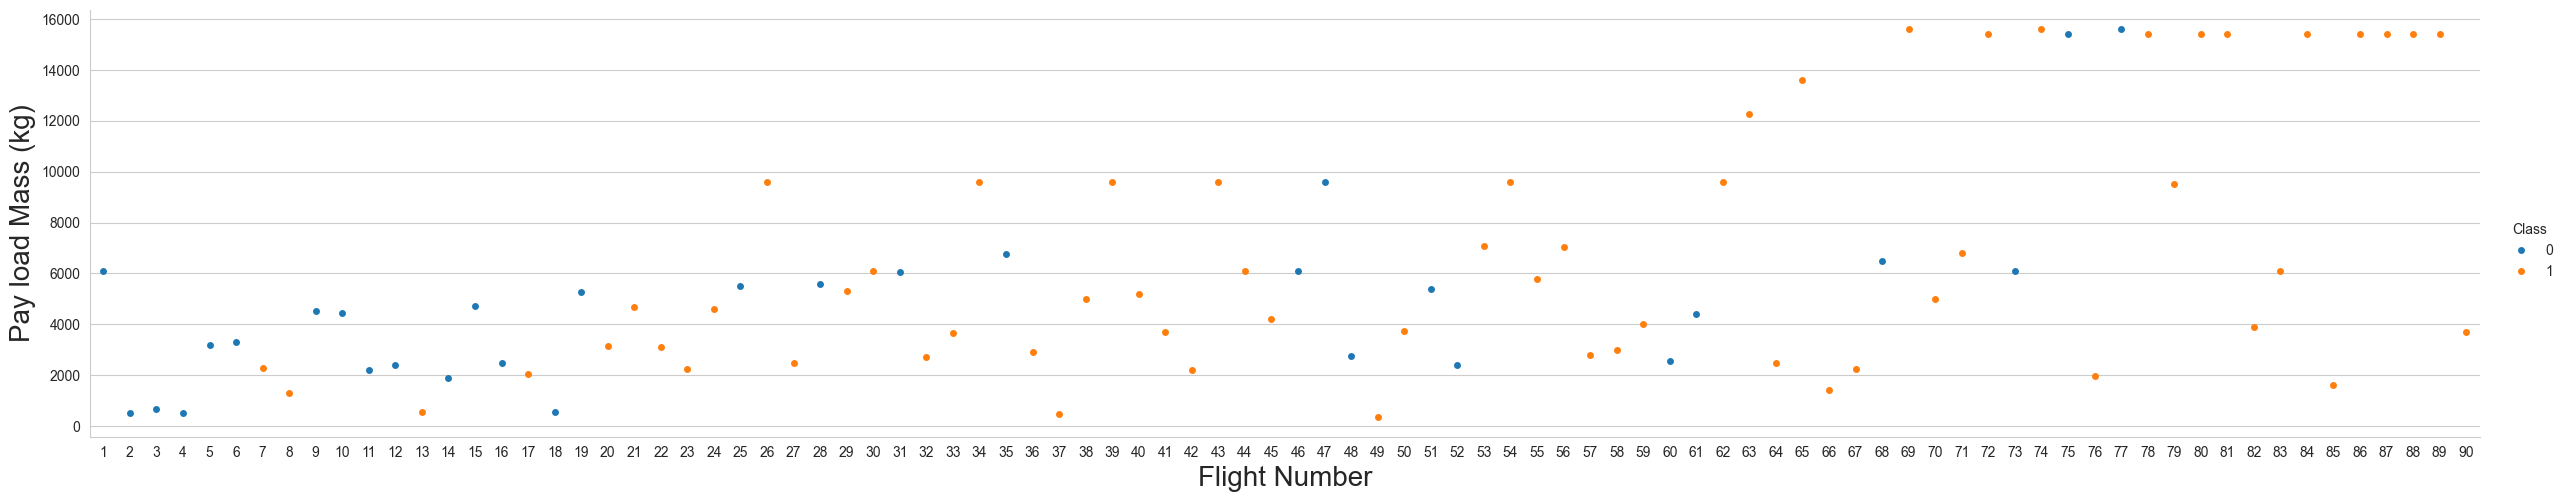

In [3]:
plt.figure()
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Pay load Mass (kg)", fontsize=20)
plt.savefig("chart_flightnumber_payload.png", dpi=150, bbox_inches="tight")
plt.show()

### Task 1: Flight Number vs. Launch Site

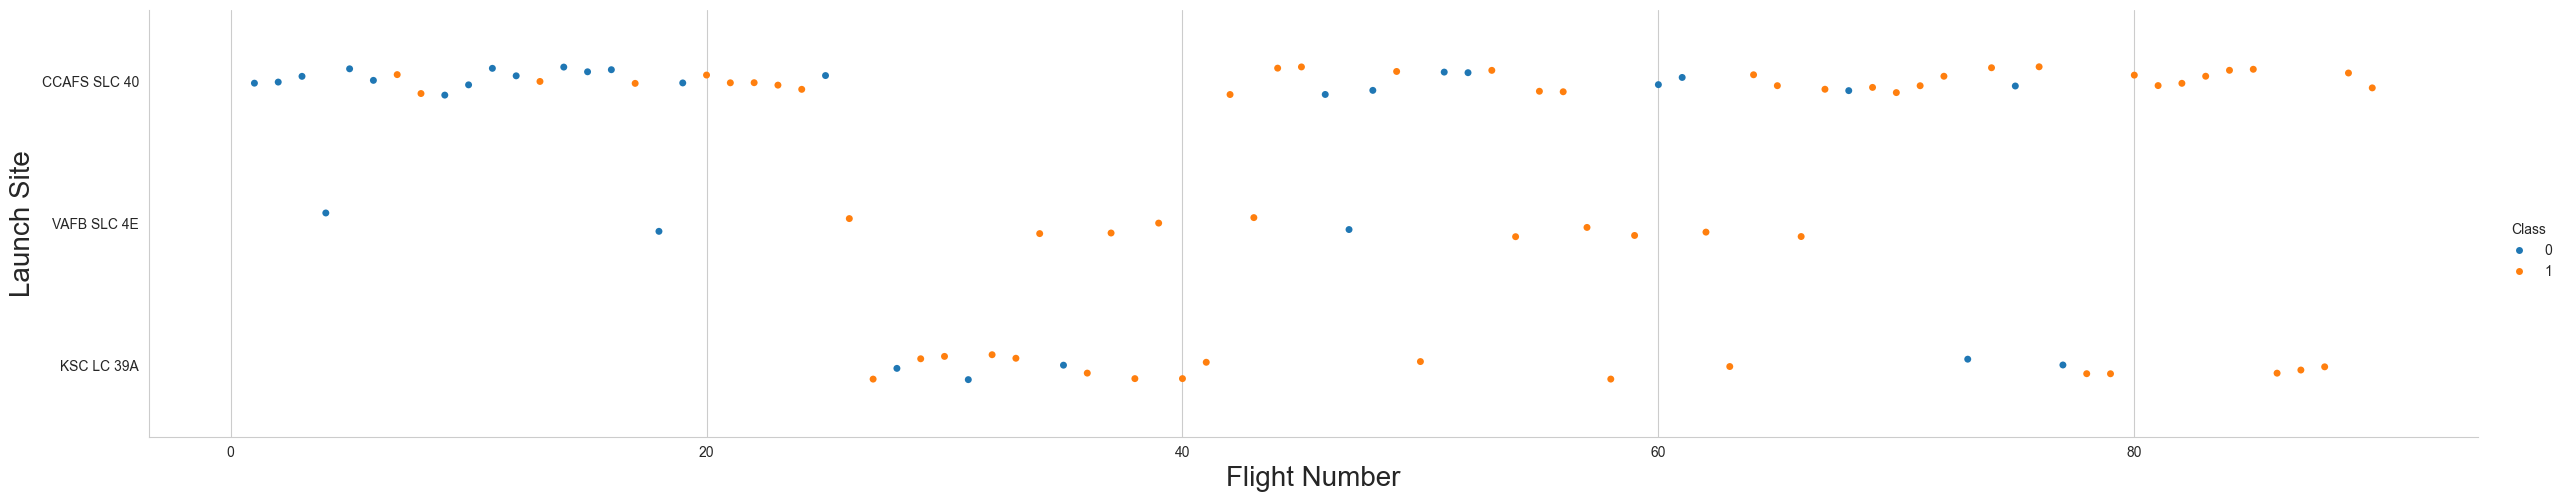

In [4]:
sns.catplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df, aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.savefig("chart_flightnumber_launchsite.png", dpi=150, bbox_inches="tight")
plt.show()

### Task 2: Payload Mass vs. Launch Site

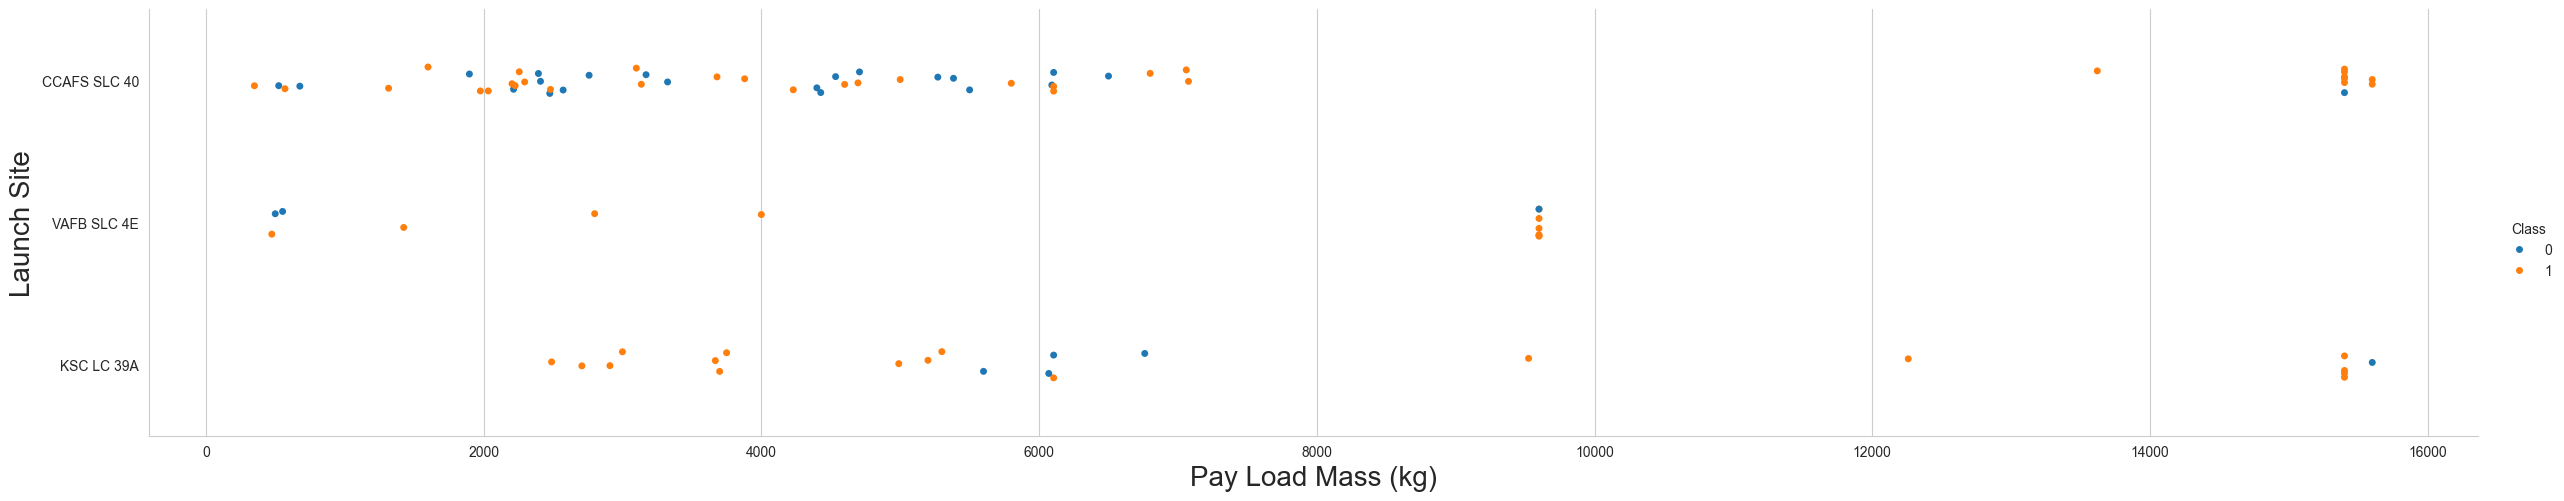

In [5]:
sns.catplot(y="LaunchSite", x="PayloadMass", hue="Class", data=df, aspect=5)
plt.xlabel("Pay Load Mass (kg)", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.savefig("chart_payload_launchsite.png", dpi=150, bbox_inches="tight")
plt.show()

VAFB-SLC launches no rockets with payload mass greater than ~10,000 kg — that site is only used for lighter, polar-orbit missions.

### Task 3: Success rate by orbit type

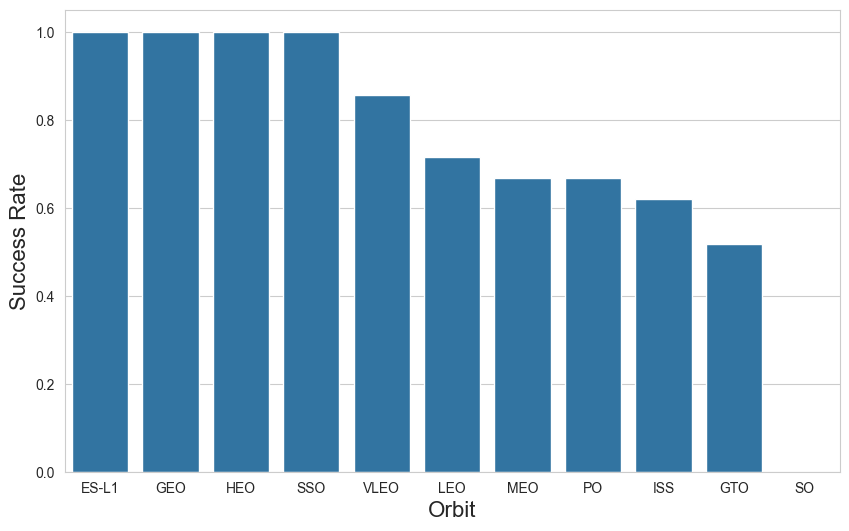

,Orbit,Class
0,ES-L1,1.000000
1,GEO,1.000000
3,HEO,1.000000
9,SSO,1.000000
10,VLEO,0.857143
5,LEO,0.714286
6,MEO,0.666667
7,PO,0.666667
4,ISS,0.619048
2,GTO,0.518519


In [6]:
orbit_success_rate = df.groupby('Orbit')['Class'].mean().reset_index().sort_values('Class', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Orbit', y='Class', data=orbit_success_rate, order=orbit_success_rate['Orbit'])
plt.xlabel("Orbit", fontsize=16)
plt.ylabel("Success Rate", fontsize=16)
plt.savefig("chart_orbit_success_rate.png", dpi=150, bbox_inches="tight")
plt.show()
orbit_success_rate

### Task 4: Flight Number vs. Orbit type

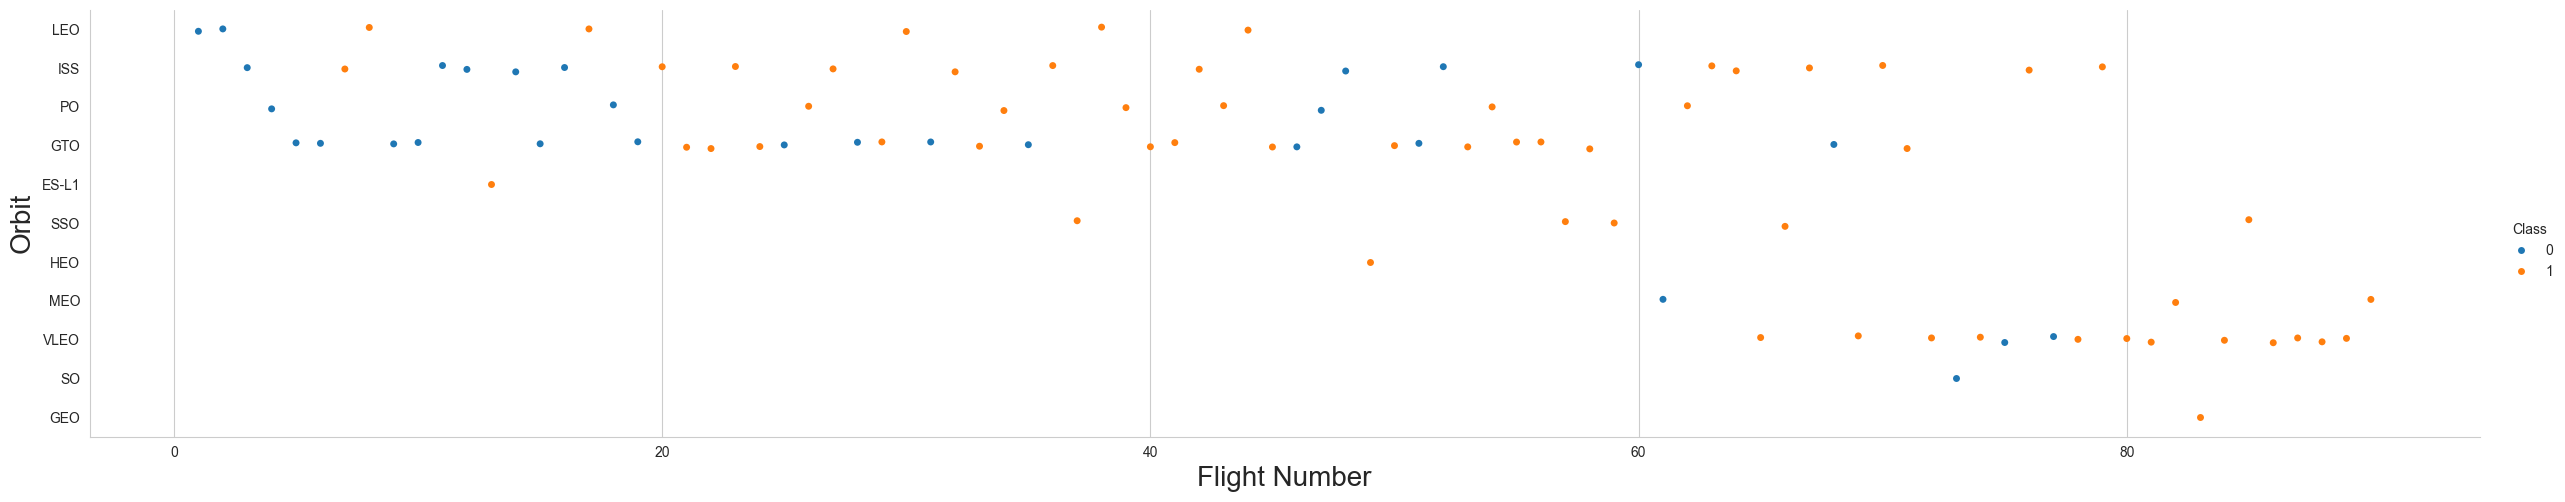

In [7]:
sns.catplot(y="Orbit", x="FlightNumber", hue="Class", data=df, aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Orbit", fontsize=20)
plt.savefig("chart_flightnumber_orbit.png", dpi=150, bbox_inches="tight")
plt.show()

In the LEO orbit, success correlates with flight number. In GTO there's no clear relationship between flight number and success.

### Task 5: Payload Mass vs. Orbit type

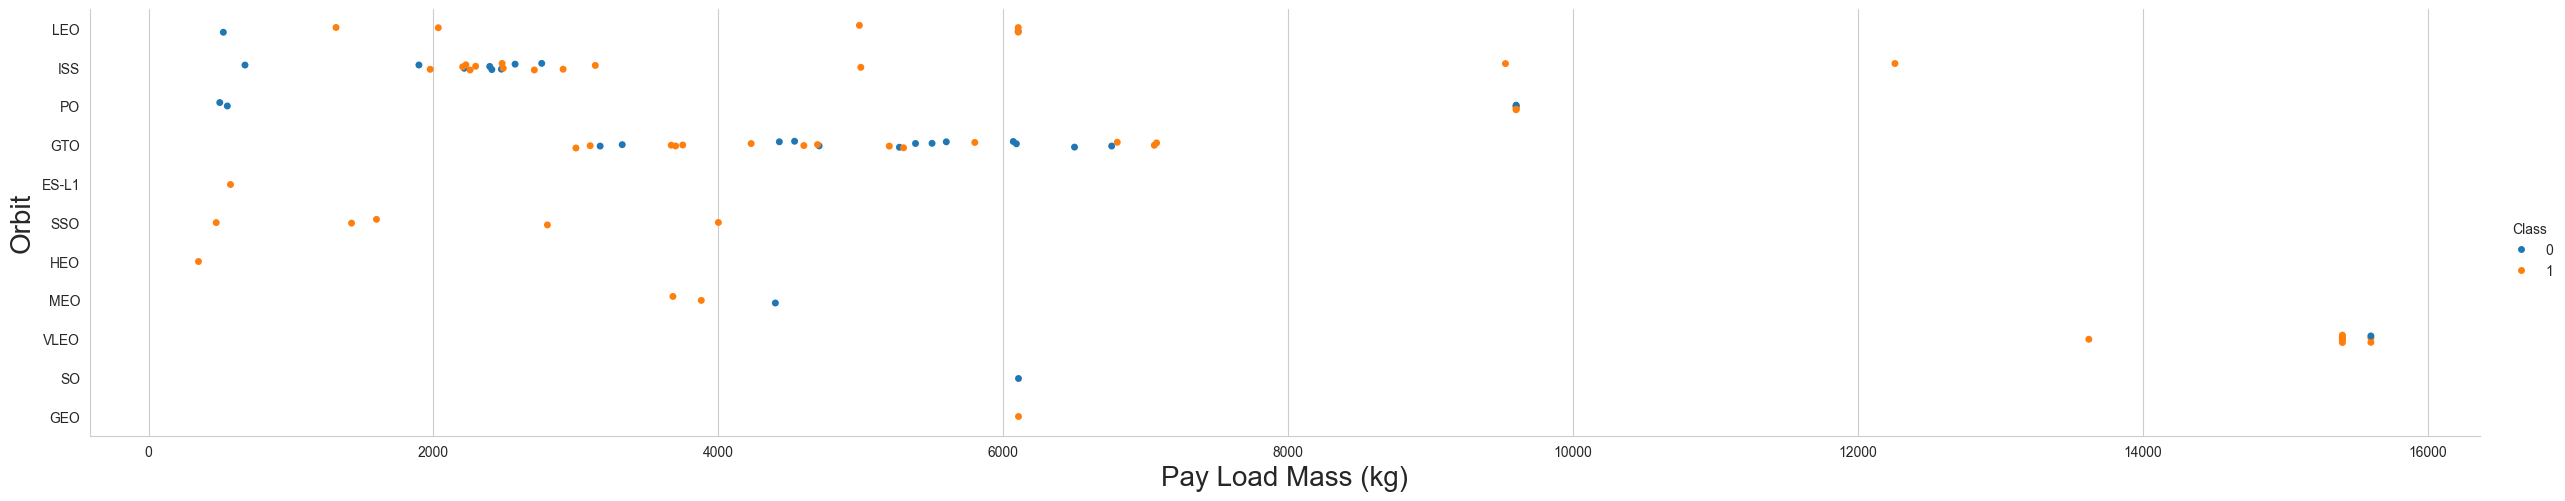

In [8]:
sns.catplot(y="Orbit", x="PayloadMass", hue="Class", data=df, aspect=5)
plt.xlabel("Pay Load Mass (kg)", fontsize=20)
plt.ylabel("Orbit", fontsize=20)
plt.savefig("chart_payload_orbit.png", dpi=150, bbox_inches="tight")
plt.show()

With heavy payloads, success rates are higher for Polar, LEO and ISS orbits. For GTO both outcomes appear across the payload range.

### Task 6: Launch success yearly trend

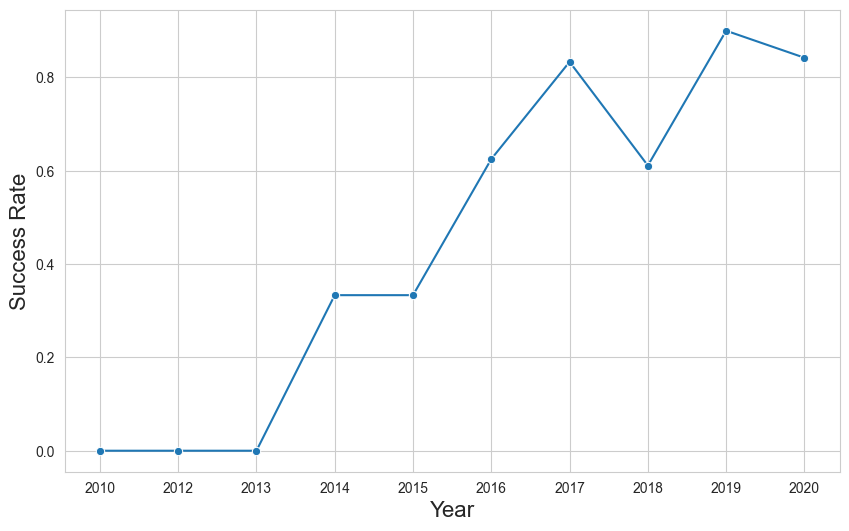

,Date,Class
0,2010,0.000000
1,2012,0.000000
2,2013,0.000000
3,2014,0.333333
4,2015,0.333333
5,2016,0.625000
6,2017,0.833333
7,2018,0.611111
8,2019,0.900000
9,2020,0.842105


In [9]:
year = [i.split("-")[0] for i in df["Date"]]
df['Date'] = year

yearly_success_rate = df.groupby('Date')['Class'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(x='Date', y='Class', data=yearly_success_rate, marker='o')
plt.xlabel("Year", fontsize=16)
plt.ylabel("Success Rate", fontsize=16)
plt.savefig("chart_yearly_success_trend.png", dpi=150, bbox_inches="tight")
plt.show()
yearly_success_rate

The success rate climbed steadily from 2013 through 2020 as SpaceX refined the landing process.

## Feature Engineering

In [10]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs',
                'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### Task 7: One-hot encode categorical columns

In [11]:
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


### Task 8: Cast all numeric columns to float64

In [12]:
features_one_hot = features_one_hot.astype('float64')
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
features_one_hot.to_csv('dataset_part_3.csv', index=False)
print('Saved dataset_part_3.csv —', features_one_hot.shape)

Saved dataset_part_3.csv — (90, 80)
